In [ ]:
import nest_asyncio
nest_asyncio.apply()



In [ ]:
!pip install pytorch_lightning

In [7]:
import pandas as pd
import glob
import os

# Define the specific keywords you are looking for
modalities = ['ecg', 'us_abdo', 'us_app', 'us_testes', 'xray_arm']
set_types = ['train', 'test', 'val', 'tech_val']

# Initialize the nested dictionary
labeled_dataframes = {s: {} for s in modalities}

# Get all csv files
files = glob.glob("./data/*.csv")

for f in files:
    # 1. Identify the Set Type
    # We check for 'tech_val' first because 'val' is a substring of it
    current_set = None
    if "tech_val" in f:
        current_set = "tech_val"
    elif "train" in f:
        current_set = "train"
    elif "test" in f:
        current_set = "test"
    elif "val" in f:
        current_set = "val"
        
    # 2. Identify the Modality
    current_modality = None
    for m in modalities:
        if m in f:
            current_modality = m
            break
            
    # 3. Load if both were found
    if current_set and current_modality:
        labeled_dataframes[current_modality][current_set] = pd.read_csv(f)
        print(f"Loaded: {f} -> data['{current_modality}']['{current_set}']")


Loaded: ./data/train_data_ecg.csv -> data['ecg']['train']
Loaded: ./data/val_data_ecg.csv -> data['ecg']['val']
Loaded: ./data/test_data_ecg.csv -> data['ecg']['test']
Loaded: ./data/tech_val_data_ecg.csv -> data['ecg']['tech_val']
Loaded: ./data/train_data_us_abdo.csv -> data['us_abdo']['train']
Loaded: ./data/val_data_us_abdo.csv -> data['us_abdo']['val']
Loaded: ./data/test_data_us_abdo.csv -> data['us_abdo']['test']
Loaded: ./data/tech_val_data_us_abdo.csv -> data['us_abdo']['tech_val']
Loaded: ./data/train_data_us_app.csv -> data['us_app']['train']
Loaded: ./data/val_data_us_app.csv -> data['us_app']['val']
Loaded: ./data/test_data_us_app.csv -> data['us_app']['test']
Loaded: ./data/tech_val_data_us_app.csv -> data['us_app']['tech_val']
Loaded: ./data/train_data_us_testes.csv -> data['us_testes']['train']
Loaded: ./data/val_data_us_testes.csv -> data['us_testes']['test']
Loaded: ./data/test_data_us_testes.csv -> data['us_testes']['test']
Loaded: ./data/tech_val_data_us_testes.csv 

In [14]:
feature_map = {
    'id':['contact_serial_number'],
    'categorical': [
        ('sex', 2),
        ('canadian_triage_acuity_scale',5),
        ('means_of_arrival',3),
        # ('care_area',)
        ('preferred_language',5)
    ],
    'binary': [
        # 'is_abnormal_weight',
        # 'is_abnormal_latest_temperature',
        # 'is_abnormal_latest_pulse',
        # 'is_abnormal_latest_blood_pressure',
        # 'is_abnormal_latest_respiratory_rate',
        # 'is_abnormal_latest_oxygen_saturation',
        'is_suspicion_covid'
    ],
    'numerical':[
        'weight_value',
        'latest_temperature_value',
        'latest_pulse_value',
        'latest_blood_pressure_systolic_value',
        'latest_blood_pressure_diastolic_value',
        'latest_respiratory_rate_value',
        'latest_oxygen_saturation_value',
        'age_years',
        'age_months',
        'age_weeks',
        'age_days'
    ],
    'pc':['postal_code'],
    'text':[
        'note',
        'presenting_complaint',
        'chief_complaint'
    ],
    'datetime':[
        "arrival_datetime",
        # "triage2_end_datetime"
    ],
    
}

In [15]:
import numpy as np
import torch
import torch.nn as nn

In [16]:

class CategoricalEncoder:
    def __init__(self, features: list[str], top_k: list[int]):
        self.features = features
        self.top_k = top_k
        self.vocab_ = {}
        self.mapping_ = {}

    def fit(self, df: pd.DataFrame):
        for idx, col in enumerate(self.features):
            top = df[col].value_counts().nlargest(self.top_k[idx]).index.tolist()
            vocab = ["Other"]
            if "language" in col.lower():
                vocab = vocab +['Missing']
            vocab = vocab + sorted(top)
            self.vocab_[col] = vocab
            self.mapping_[col] = {cat: idx for idx, cat in enumerate(vocab)}
        return self
     
    def transform(self, df: pd.DataFrame) -> torch.Tensor:
        encs = []
        df_ = df[self.features].copy()
        for col in self.features:
            m = self.mapping_[col]
            df_[col] = df_[col].astype(str).fillna("Missing")
            # m.get(x, 0) the 0 is for other in the vocab
            # to handle the language that are not common enough
            # to be in the top K
            enc = df_[col].map(lambda x: m.get(x, 0)).astype(int)
            encs.append(enc)
        
        arr = np.stack(encs, axis=1)
        return torch.tensor(arr, dtype=torch.long)


In [17]:

class DateTimeCyclicEncoder:
    """
    Encode datetime columns into cyclical features:
        - hour_of_day     → sin/cos(2π * hour/24)
        - day_of_week     → sin/cos(2π * dow/7)
        - day_of_month   → sin/cos(2π * (dom-1)/31)
        - week_of_year   → sin/cos(2π * (woy-1)/52)
        - month_of_year → sin/cos(2π * (moy-1)/12)
    Outputs a Tensor of shape [n_rows, n_features*10].
    """
    def __init__(self, features: list[str]):
        self.features = features
        self.transformed_features_name = [
            f"{prefix}_{time}_{feature}"
            for feature in self.features
            for time in ["hour", "dow", "dom", "woy", "moy"]
            for prefix in ["sin", "cos"]
        ]

    def fit(self, df: pd.DataFrame, y=None):
        return self

    def transform(self, df: pd.DataFrame) -> torch.Tensor:
        all_feats = []
        for col in self.features:
            s = pd.to_datetime(df[col], errors='coerce').infer_objects(copy=False).fillna(pd.Timestamp(0))
            # hour of day
            h = s.dt.hour.astype(float)
            all_feats.append(np.sin(2*np.pi * h / 24))
            all_feats.append(np.cos(2*np.pi * h / 24))
            # day of week
            w = s.dt.dayofweek.astype(float)
            all_feats.append(np.sin(2*np.pi * w / 7))
            all_feats.append(np.cos(2*np.pi * w / 7))
            # day of month
            d = (s.dt.day - 1).astype(float)
            all_feats.append(np.sin(2*np.pi * d / 31))
            all_feats.append(np.cos(2*np.pi * d / 31))
            # week of year (ISO week)
            y = (s.dt.isocalendar().week - 1).astype(float)
            all_feats.append(np.sin(2*np.pi * y / 52))
            all_feats.append(np.cos(2*np.pi * y / 52))
            # month of year
            m = (s.dt.month - 1).astype(float)
            all_feats.append(np.sin(2*np.pi * m / 12))
            all_feats.append(np.cos(2*np.pi * m / 12))
        arr = np.stack(all_feats, axis=1)   # shape [n_rows, len(features)*10]
        return torch.tensor(arr, dtype=torch.float32)



In [18]:

class NumericalEncoder:
    def __init__(self, features: list[str], fill_value: float = -1.0):
        self.features = features
        self.fill_value = fill_value
   
    def fit(self, df: pd.DataFrame): return self

    def transform(self, df: pd.DataFrame) -> torch.Tensor:
        
        arr = df[self.features].astype(float).fillna(self.fill_value).values.astype(np.float32)
        
        return torch.tensor(arr)



In [19]:
from src.mlmd.train.data.mlmd_labels import create_mlmd_engine
from src.mlmd.inference.settings import Settings
settings = Settings()

In [26]:

from sqlalchemy.orm import Session
from src.mlmd.train.data.data_classes.pc_distance_data_classes import PostalPrefixDistance
from json import loads

class PostalPrefixDistanceEncoder:
    def __init__(self, path_encoder, feature: str):
        self.path_encoder = path_encoder
        self.feature_name = feature
        self.transformed_features_name = [
            "log_mean_distance", "log_var_distance"
        ]
        self.lookup_ = {}
        self.default_mean = 0.0
        self.default_var = 0.0

    def fit(self, df: pd.DataFrame):

        with open(self.path_encoder) as f :
            encoder_data = loads(f.read())
        self.default_mean = encoder_data['post_enc_state']['default_mean']
        self.default_var = encoder_data['post_enc_state']['default_var']

        self.lookup_ = encoder_data['post_enc_state']['lookup']
        return self
    
    def transform(self, df: pd.DataFrame) -> torch.Tensor:
        prefixes = df[self.feature_name].astype(str).fillna('').str[:3].str.upper()
        out = []
        for p in prefixes:
            if p in self.lookup_:
                m,v = self.lookup_[p]
                out.append([np.log(m) if m is not None else -1,
                            np.log(v) if v is not None else -1])
            else:
                # out.append([
                # np.log(self.default_mean), 
                # np.log(self.default_var)
                # ])
                out.append([-1,-1])
        arr = np.array(out, dtype=np.float32)
        return torch.tensor(arr)
    




In [21]:

from src.mlmd.train.data.encoders.nlp_bert import batch_predict

class CompositeEncoder:
    """
    Wraps all sub-encoders: CategoricalEncoder, NumericalEncoder,
    PostalPrefixDistanceLookup, plus the BERT-via-MLflow text embedder.
    Provides fit(), transform(), save() and load().
    """
    def __init__(
            self,
            feature_map: dict,
            mlflow_endpoint: str,
            path_encoder:None,
            num_fill_value: float = -1.0
        ):
        # identify feature groups
        self.id_cols = feature_map['id']
        self.cat_feats = [e[0] for e in feature_map.get('categorical',[])]
        self.cat_top_k = [e[1] for e in feature_map.get('categorical',[])]
        self.num_feats = feature_map.get("numerical", [])
        self.num_fill_value = num_fill_value
        self.text_feats = feature_map.get("text", [])
        self.dt_feats = feature_map.get("datetime", [])
        postal_col = feature_map.get("pc",[])

        self.postal_col = postal_col[0] if len(postal_col) > 0 else None
        self.mlflow_endpoint = mlflow_endpoint

        # instantiate the individual encoders
        self.cat_enc = CategoricalEncoder(self.cat_feats, self.cat_top_k)
        self.num_enc = NumericalEncoder(self.num_feats, self.num_fill_value)
        self.dt_enc = DateTimeCyclicEncoder(self.dt_feats)
        self.post_enc = PostalPrefixDistanceEncoder(path_encoder, self.postal_col)


        self._text_cache = { feature_name: {} for feature_name in self.text_feats }


    def __generate_transformed_feature_name(self):
        self.tabular_features_name = []
        self.tabular_features_name.extend(self.cat_enc.features)
        self.tabular_features_name.extend(self.num_enc.features)
        self.tabular_features_name.extend(self.dt_enc.transformed_features_name)
        self.tabular_features_name.extend(self.post_enc.transformed_features_name)
        
        self.text_features_name = []
        if len(self.text_feats) > 0:
            text_emb = batch_predict([""], self.mlflow_endpoint)
            for f_name in self.text_feats:
                self.text_features_name.append([f"{f_name}_nlp_{i}" for i in range(text_emb.shape[1]) ])




    def fit(self, df: pd.DataFrame):
        self.cat_enc.fit(df)
        self.num_enc.fit(df)
        self.dt_enc.fit(df)
        self.post_enc.fit(df)
        self.__generate_transformed_feature_name()
        return self
        
    def transform(self, df: pd.DataFrame):

        id_frame = df[self.id_cols]
        
        X_cat = self.cat_enc.transform(df)
        X_num = self.num_enc.transform(df)
        X_dt = self.dt_enc.transform(df)
        X_post = self.post_enc.transform(df)
        tabular_x = torch.cat([X_cat, X_num, X_dt, X_post], dim=1)
        text_x = []

        for feature in self.text_feats:
            texts = df[feature].astype(str).fillna('').tolist()
            text_x.append(batch_predict(texts, self.mlflow_endpoint))

        text_x = torch.stack(text_x, dim=1)

        return id_frame, tabular_x, text_x
    
    def transform_one(self, row: pd.Series|pd.DataFrame):
        row_df = row.to_frame().T
        id_frame, tabular_x, text_x = self.transform(row_df)
        return id_frame.iloc[0], tabular_x[0], text_x[0]

    def describe(self) -> dict:
        """
        Return a summary of each encoder’s configuration:
          - categorical vocabularies
          - numerical fill value
          - postal lookup defaults & prefixes
          - text features & MLflow endpoint
        """
        info = {
            'categorical': {c: self.cat_enc.vocab_[c] for c in self.cat_feats},
            'numerical':   {'features': self.num_enc.features, 'fill_value': self.num_enc.fill_value},
            'datetime':    {'features': self.dt_enc.features,
                            'cycles': self.dt_enc.transformed_features_name},
            'postal':       None,
            'text':        {'features': self.text_feats, 'endpoint': self.mlflow_endpoint}
        }
        if self.post_enc:
            info['postal'] = {
                'postal_col': self.post_enc.feature_name,
                'default_mean': self.post_enc.default_mean,
                'default_var':  self.post_enc.default_var,
                'prefixes': len(self.post_enc.lookup_.keys())
            }
        return info


In [ ]:
encoder = CompositeEncoder(
    feature_map=feature_map,
    mlflow_endpoint="http://127.0.0.1:23002/invocations",
    path_encoder="./encoder.json",
    num_fill_value=-1
)

encoder.fit(labeled_dataframes["ecg"]['train'])
# encoder.describe()


In [31]:
encoder.describe()

{'categorical': {'sex': ['Other', 'F', 'M'],
  'canadian_triage_acuity_scale': ['Other', 1.0, 2.0, 3.0, 4.0, 5.0],
  'means_of_arrival': ['Other', 'Ambulance', 'Ambulatory', 'Transfer'],
  'preferred_language': ['Other',
   'Missing',
   'Arabic',
   'Chinese - Cantonese',
   'Chinese - Mandarin',
   'English',
   'Spanish']},
 'numerical': {'features': ['weight_value',
   'latest_temperature_value',
   'latest_pulse_value',
   'latest_blood_pressure_systolic_value',
   'latest_blood_pressure_diastolic_value',
   'latest_respiratory_rate_value',
   'latest_oxygen_saturation_value',
   'age_years',
   'age_months',
   'age_weeks',
   'age_days'],
  'fill_value': -1},
 'datetime': {'features': ['arrival_datetime'],
  'cycles': ['sin_hour_arrival_datetime',
   'cos_hour_arrival_datetime',
   'sin_dow_arrival_datetime',
   'cos_dow_arrival_datetime',
   'sin_dom_arrival_datetime',
   'cos_dom_arrival_datetime',
   'sin_woy_arrival_datetime',
   'cos_woy_arrival_datetime',
   'sin_moy_arriv

In [29]:
class AttentionPooling(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.query = nn.Parameter(torch.randn(1, 1, embed_dim))  # (1, 1, D)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        """
        x: (B, T, D) – sequence of fused vectors
        returns: (B, D) – weighted sum
        """
        B, T, D = x.shape
        # Repeat query to match batch size: (B, 1, D)
        q = self.query.expand(B, -1, -1)
        # Compute attention scores: (B, 1, D) @ (B, D, T) -> (B, 1, T)
        attn_scores = torch.bmm(q, x.transpose(1, 2))
        attn_weights = self.softmax(attn_scores)  # (B, 1, T)
        # Weighted sum over sequence: (B, 1, T) @ (B, T, D) -> (B, 1, D)
        weighted_sum = torch.bmm(attn_weights, x)  # (B, 1, D)
        return weighted_sum.squeeze(1)  # (B, D)


In [30]:
class ClassificationHead(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim // 2, 1)
        )
        
    def forward(self, x):
        logits = self.net(x).squeeze(-1)
        return logits

In [ ]:
import torch
import torch.nn as nn
class MultiModalFusionTransformer(nn.Module):
    def __init__(self, tabular_dim, text_dim, hidden_dim=1024, num_layers=4, n_heads=4, ff_dims=None, dropout=0.1):
        super().__init__()

        self.tabular_proj = nn.Sequential(
            nn.Linear(tabular_dim, 2 * text_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(2 * text_dim, text_dim),
            nn.ReLU()
        )

        self.pos_embed = nn.Parameter(torch.zeros(1, 4, text_dim))
        nn.init.xavier_uniform_(self.pos_embed)

        if ff_dims is None:
            ff_dims = [1024] * num_layers

        self.layers = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=text_dim,
                nhead=n_heads,
                dim_feedforward=ff_dims[i],
                dropout=dropout,
                batch_first=True
            )
            for i in range(num_layers)
        ])

        self.attn_pool = AttentionPooling(text_dim)

        self.classifier = nn.Sequential(
            nn.LayerNorm(text_dim),
            nn.Linear(text_dim, 1)  # Binary classification
        )


    def forward(self, tabular_x, text1_x, text2_x, text3_x):
        tabular_proj = self.tabular_proj(tabular_x).unsqueeze(1)
        text_x = torch.stack([text1_x, text2_x, text3_x], dim=1)
        x = torch.cat([tabular_proj, text_x], dim=1)
        x = x + self.pos_embed
        for layer in self.layers:
            x = layer(x)

        pooled = self.attn_pool(x)
        return self.classifier(pooled).squeeze(-1)

        tabular_proj = self.tabular_proj(tabular_x)
        x = torch.cat([tabular_proj, text1_x, text2_x, text3_x], dim=1)

        return self.classifier(x).squeeze(-1)



In [33]:
tabular_dim = len(encoder.tabular_features_name)
text_dim = len(encoder.text_features_name[0])

In [35]:
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, Callback, ModelCheckpoint
from pytorch_lightning.loggers import MLFlowLogger
import mlflow.pytorch

In [36]:
from torchmetrics.classification import BinaryAUROC, BinaryAveragePrecision, BinaryF1Score


In [37]:
class FusionLightningModule(pl.LightningModule):
    def __init__(self, tabular_dim, text_dim, pos_weight=None, lr=1e-3, use_pos_weight=False):
        super().__init__()
        self.save_hyperparameters()

        self.model = MultiModalFusionTransformer(
            tabular_dim=tabular_dim,
            text_dim=text_dim,
            hidden_dim=1024,
            num_layers=4,
            n_heads=4,
            ff_dims=None,
            dropout=0.1
        )

        # Optional: use pos_weight or not
        self.use_pos_weight = use_pos_weight
        if self.use_pos_weight and pos_weight is not None:
            capped_weight = min(pos_weight, 10.0)
            self.register_buffer("pos_weight", torch.tensor(capped_weight))
            self.criterion = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight)
        else:
            self.criterion = nn.BCEWithLogitsLoss()

        self.train_losses = []
        self.val_losses = []
        self.test_losses = []
        # Metrics
        self.auroc = BinaryAUROC()
        self.auprc = BinaryAveragePrecision()
        self.f1 = BinaryF1Score()

    def forward(self, tabular_x, text1_x, text2_x, text3_x):
        return self.model(tabular_x, text1_x, text2_x, text3_x)

    def training_step(self, batch, batch_idx):
        tabular_x, text1_x, text2_x, text3_x, labels = batch
        logits = self(tabular_x, text1_x, text2_x, text3_x)
        loss = self.criterion(logits, labels.float())
        self.log("train_loss", loss, on_epoch=True, prog_bar=True)


        probs = torch.sigmoid(logits)
        self.auroc.update(probs, labels.int())
        self.auprc.update(probs, labels.int())
        self.f1.update(probs, labels.int())

        self.log("train_loss", loss, on_epoch=True, prog_bar=True)
        self.log("train_auroc", self.auroc.compute(), prog_bar=True, on_epoch=True)
        self.log("train_auprc", self.auprc.compute(), prog_bar=True, on_epoch=True)
        self.log("train_f1", self.f1.compute(), prog_bar=True, on_epoch=True)
        self.auroc.reset()
        self.auprc.reset()
        self.f1.reset()
        return loss

    def validation_step(self, batch, batch_idx):
        tabular_x, text1_x, text2_x, text3_x, labels = batch
        logits = self(tabular_x, text1_x, text2_x, text3_x)
        probs = torch.sigmoid(logits)
        loss = self.criterion(logits, labels.float())

        # Log sample outputs (once per epoch)
        if batch_idx == 0:
            with torch.no_grad():
                pos_indices = (labels == 1).nonzero(as_tuple=True)[0]
                print(pos_indices)
                neg_indices = (labels == 0).nonzero(as_tuple=True)[0]

                k = 5  # Number of samples from each class (or fewer if unavailable)
                num_pos = min(len(pos_indices), k)
                num_neg = min(len(neg_indices), k)

                sampled_indices = torch.cat([
                    pos_indices[torch.randperm(len(pos_indices))[:num_pos]],
                    neg_indices[torch.randperm(len(neg_indices))[:num_neg]]
                ])

                sampled_probs = probs[sampled_indices].detach().cpu().numpy()
                sampled_labels = labels[sampled_indices].cpu().numpy()

                self.print(f"[VAL] Logits stats: min={logits.min():.2f}, max={logits.max():.2f}, mean={logits.mean():.2f}")
                self.print("Sample probs (mixed):", sampled_probs)
                self.print("Sample labels (mixed):", sampled_labels)

        self.auroc.update(probs, labels.int())
        self.auprc.update(probs, labels.int())
        self.f1.update(probs, labels.int())

        self.log("val_loss", loss, on_epoch=True, prog_bar=True)
        self.log("val_auroc", self.auroc.compute(), prog_bar=True, on_epoch=True)
        self.log("val_auprc", self.auprc.compute(), prog_bar=True, on_epoch=True)
        self.log("val_f1", self.f1.compute(), prog_bar=True, on_epoch=True)
        self.auroc.reset()
        self.auprc.reset()
        self.f1.reset()
        return loss


    def test_step(self, batch, batch_idx):
        tabular_x, text1_x, text2_x, text3_x, labels = batch
        logits = self(tabular_x, text1_x, text2_x, text3_x)
        loss = self.criterion(logits, labels.float())
        self.log("test_loss", loss, on_epoch=True, prog_bar=True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.RAdam(self.parameters(), lr=self.hparams.lr, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.1,
            patience=2,
            min_lr=0.0001
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss"
            }
        }


In [38]:
import numpy as np

In [39]:
class MetricsLogger(Callback):
    def on_train_epoch_end(self, trainer, pl_module):
        # After each train epoch, Lightning has aggregated "train_loss"
        metrics = trainer.callback_metrics
        if "train_loss" in metrics:
            pl_module.train_losses.append(metrics["train_loss"].cpu().item())

    def on_validation_epoch_end(self, trainer, pl_module):
        metrics = trainer.callback_metrics
        if "val_loss" in metrics:
            pl_module.val_losses.append(metrics["val_loss"].cpu().item())

    def on_test_epoch_end(self, trainer, pl_module):
        metrics = trainer.callback_metrics
        if "test_loss" in metrics:
            pl_module.test_losses.append(metrics["test_loss"].cpu().item())


In [40]:
from torch.utils.data import Dataset

class MLMDDataset(Dataset):
    def __init__(self, df, encoder, batching=True):
        self.df = df.reset_index(drop=True)
        self.encoder = encoder
        self.batching = batching

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        if self.batching:
            return self.df.loc[idx, :]
        
        row = self.df.iloc[idx, :]
        features = row.iloc[:-1]
        label = row.iloc[-1]
        _, tabular_x, text_x = self.encoder.transform_one(features)
        if not isinstance(tabular_x, torch.Tensor):
            tabular_x = torch.tensor(tabular_x, dtype=torch.float32)
        if not isinstance(text_x, torch.Tensor):           
            text_x = torch.tensor(text_x, dtype=torch.float32)
        y = torch.tensor(label, dtype=torch.float32)
        return tabular_x, text_x[0,:], text_x[1,:], text_x[2,:], y
    
        

In [41]:
def collate_fn(batch, encoder, batching):
    if not batching:
        return batch
    # batch is a list of raw items
    # Convert to appropriate format: pandas.DataFrame, list ofe dicts, etc.
    batch_df = pd.DataFrame(batch)  # assuming each item is a dict

    x = batch_df.loc[:, batch_df.columns[:-1]]
    label = batch_df[batch_df.columns[-1]].to_numpy()

    _, tabular_x, text_x = encoder.transform(x)
    y = torch.tensor(label, dtype=torch.float32)
    return tabular_x, text_x[:,0,:], text_x[:,1,:], text_x[:,2,:], y

In [42]:
from torch.utils.data import DataLoader
from functools import partial

In [43]:
def create_logger_and_callbacks(mlmd_name):
    mlflow_logger = MLFlowLogger(
        experiment_name=f"{mlmd_name}_multimodal_fusion_experiment",
        run_name=f"{mlmd_name}_fusion_transformer_run",
        tracking_uri=None 
    )

    early_stop_callback = EarlyStopping(
        monitor="val_auprc",
        min_delta=0.0005,
        patience=3,
        mode="max",
        strict=True,
        verbose=True
    )

    checkpoint_callback = ModelCheckpoint(
        monitor="val_auprc",
        mode="max",
        save_top_k=1,
        filename=mlmd_name+"-fusion-transformer-{epoch:02d}-{val_loss:.3f}"
    )

    metrics_logger = MetricsLogger()

    return mlflow_logger, [early_stop_callback, checkpoint_callback, metrics_logger]

In [44]:
from torch.utils.data import Subset
def create_downsampled_dataset(dataset, label_index: int = -1, ratio=1.0, down_sample=True):
    if not down_sample:
        return dataset
    pos_indices = []
    neg_indices = []

    for i in range(len(dataset)):
        label = dataset[i][label_index]
        if isinstance(label, torch.Tensor):
            label = label.item()
        (pos_indices if label == 1 else neg_indices).append(i)

    # Downsample negatives
    np.random.shuffle(neg_indices)
    max_neg = int(len(pos_indices) * ratio)
    sampled_neg_indices = neg_indices[:max_neg]

    selected_indices = pos_indices + sampled_neg_indices
    np.random.shuffle(selected_indices)

    return Subset(dataset, selected_indices)

In [45]:
pos_weight = {}
dataloader = {}
for mlmd_name in labeled_dataframes:
    dataloader[mlmd_name] = {}
    for setname in labeled_dataframes[mlmd_name]:
        ds= MLMDDataset(labeled_dataframes[mlmd_name][setname], encoder, batching=True)
        # ds_s = create_downsampled_dataset(ds, ratio=4, down_sample=setname=="train")
        dataloader[mlmd_name][setname] = DataLoader(ds, batch_size=64, shuffle=setname=="train", num_workers=76, collate_fn=partial(collate_fn, encoder=ds.encoder, batching=ds.batching))

        if setname=="train":
            label_counts = labeled_dataframes[mlmd_name][setname][f'{mlmd_name.upper()}_LABEL'].value_counts()
            print(label_counts[0]/label_counts[1])
            pos_weight[mlmd_name] = label_counts[0]/label_counts[1]

pos_weight


32.06568203650336


{'ecg': np.float64(32.06568203650336)}

In [46]:
models = {}
for mlmd_name in labeled_dataframes:
    mlflow_logger, callbacks = create_logger_and_callbacks(mlmd_name)
    models[mlmd_name] = {}
    models[mlmd_name]['trainer'] = pl.Trainer(
        max_epochs=15,
        accelerator="gpu",
        devices=1,
        logger=mlflow_logger,
        callbacks=callbacks,
        log_every_n_steps=1,
        enable_progress_bar=True
    )
    models[mlmd_name]['model'] = FusionLightningModule(
        tabular_dim=tabular_dim,
        text_dim=text_dim,
        pos_weight=pos_weight[mlmd_name],
        lr=1e-3,
        use_pos_weight=True   
    )

models.keys()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


dict_keys(['ecg'])

In [ ]:
class FusionPyFuncWrapper(mlflow.pyfunc.PythonModel):  
    def load_context(self, context):  
        # context.artifacts["checkpoint"] will point to the local path of the .ckpt file  
        ckpt_path = context.artifacts["checkpoint"] 
        # mlmd_name = context.artifacts["mlmd_name"] 
        # Load the LightningModule from checkpoint  
        self.lt_model = FusionLightningModule.load_from_checkpoint(  
            ckpt_path,  weights_only=False
        )  
        # Extract the underlying nn.Module (your MultiModalFusionTransformer)  
        self.lt_model.to("cpu")
        self.lt_model.eval()
        

    def predict(self, context, model_input):  
    
        tabular_arrays = np.asarray(model_input["x_tabular"])  
        text1_arrays = np.asarray(model_input["x_text1"])  
        text2_arrays = np.asarray(model_input["x_text2"])  
        text3_arrays = np.asarray(model_input["x_text3"])  

        with torch.no_grad():  
            tabular_tensor = torch.from_numpy(tabular_arrays).float()  
            text1_tensor = torch.from_numpy(text1_arrays).float()    # or float, depending on input type  
            text2_tensor = torch.from_numpy(text2_arrays).float()  
            text3_tensor = torch.from_numpy(text3_arrays).float()  
            if len(tabular_tensor.shape) == 1:
                tabular_tensor = tabular_tensor.unsqueeze(0)
                text1_tensor = text1_tensor.unsqueeze(0)
                text2_tensor = text2_tensor.unsqueeze(0)
                text3_tensor = text3_tensor.unsqueeze(0)

            # Forward pass:  
            logits = self.lt_model(  
                tabular_tensor,  
                text1_tensor,  
                text2_tensor,  
                text3_tensor  
            )
        return logits.cpu().numpy()
      

/root/miniconda3/envs/mlmd_env/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:186: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [48]:
def save_model(trainer: pl.Trainer, model:FusionLightningModule):
    best_ckpt_path = trainer.callbacks[-1].best_model_path # checkpoint callback is the last one defined
    print(best_ckpt_path)
    if best_ckpt_path:
        # Load the LightningModule from checkpoint
        best_model = FusionLightningModule.load_from_checkpoint(best_ckpt_path, weights_only=False)
        best_model.to("cpu")
        # Log the PyTorch model (LightningModule wraps the PyTorch model internally)
        mlflow.pytorch.log_model(best_model.model, artifact_path=f"fusion_transformer_model_{mlmd_name}")
    else:
        # If no checkpoint (unlikely if training ran), fall back to model.current state
        model.to("cpu")
        mlflow.pytorch.log_model(model.model, artifact_path=f"fusion_transformer_model_{mlmd_name}")

    model_save_path = f"mlflow_save_model/mlmd_{mlmd_name}_transformer_retro_model"  

    mlflow.pyfunc.save_model(  
        path=model_save_path,  
        python_model=FusionPyFuncWrapper(),  
        artifacts={  
            "checkpoint": best_ckpt_path,

        }  
    )  

In [49]:
for mlmd_name in dataloader:
    print(mlmd_name.upper())
    models[mlmd_name]['trainer'].fit(models[mlmd_name]['model'], train_dataloaders=dataloader[mlmd_name]['train'], val_dataloaders=dataloader[mlmd_name]['val'])
    save_model(models[mlmd_name]['trainer'], models[mlmd_name]['model'] )

ECG


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type                        | Params | Mode  | FLOPs
--------------------------------------------------------------------------
0 | model     | MultiModalFusionTransformer | 3.3 M  | train | 0    
1 | criterion | BCEWithLogitsLoss           | 0      | train | 0    
2 | auroc     | BinaryAUROC                 | 0      | train | 0    
3 | auprc     | BinaryAveragePrecision      | 0      | train | 0    
4 | f1        | BinaryF1Score               | 0      | train | 0    
--------------------------------------------------------------------------
3.3 M     Trainable params
0         Non-trainable params
3.3 M     Total params
13.227    Total estimated model params size (MB)
57        Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

tensor([ 0,  2,  4,  6,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21,
        22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39,
        40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57,
        58, 59, 60, 61, 62, 63], device='cuda:0')
[VAL] Logits stats: min=-0.28, max=0.08, mean=-0.14
Sample probs (mixed): [0.4609938  0.44829088 0.44506413 0.45719594 0.4327383  0.45657134
 0.45104593 0.45633772 0.46995145]
Sample labels (mixed): [1. 1. 1. 1. 1. 0. 0. 0. 0.]


/root/miniconda3/envs/mlmd_env/lib/python3.13/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No negative samples in targets, false positive value should be meaningless. Returning zero tensor in false positive score
  warnings.warn(*args, **kwargs)


...

Validation: |          | 0/? [00:00<?, ?it/s]

tensor([ 0,  2,  4,  6,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21,
        22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39,
        40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57,
        58, 59, 60, 61, 62, 63], device='cuda:0')
[VAL] Logits stats: min=-3.46, max=4.03, mean=2.61
Sample probs (mixed): [0.9777949  0.04741758 0.9786307  0.97639924 0.98121554 0.03051328
 0.05037333 0.16416787 0.03433866]
Sample labels (mixed): [1. 1. 1. 1. 1. 0. 0. 0. 0.]


Monitored metric val_auprc did not improve in the last 3 records. Best score: 0.018. Signaling Trainer to stop.


./mlruns/607556929945857191/96ab9ac9fb68467c9a2fd81e597ee5cc/checkpoints/ecg-fusion-transformer-epoch=05-val_loss=0.224.ckpt


2026/02/05 22:00:47 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [53]:
save_model(models["ecg"]['trainer'], models["ecg"]['model'] )

./mlruns/607556929945857191/df3327aed3a24707a09b1c480f477458/checkpoints/ecg-fusion-transformer-epoch=00-val_loss=0.420.ckpt


2026/02/05 11:43:33 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [50]:
import pytorch_lightning as pl
import torch


class TestEvaluator(pl.LightningModule):
    def __init__(self, model):
        super().__init__()
        self.model = model.eval()
        self.test_outputs = []

    def forward(self, tabular_x, text1_x, text2_x, text3_x):
        with torch.no_grad():
            logits = self.model(tabular_x, text1_x, text2_x, text3_x)
            return torch.sigmoid(logits)

    def test_step(self, batch, batch_idx):
        tabular_x, text1_x, text2_x, text3_x, labels = batch
        probs = self(tabular_x, text1_x, text2_x, text3_x)
        self.test_outputs.append({"probs": probs.cpu(), "labels": labels.cpu()})

    def on_test_epoch_end(self):
        self.probs = torch.cat([o["probs"] for o in self.test_outputs]).numpy()
        self.labels = torch.cat([o["labels"] for o in self.test_outputs]).numpy()


In [51]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from IPython.display import display


def plot_metrics(mlmd_name, y_prob, y_label):
    # Sample data (replace with your actual lists)
    y_probs = np.array(y_prob)             # Probabilities
    y_true = np.array(y_label)  # Labels (0 or 1)
    # ROC and PR AUC
    roc_auc = roc_auc_score(y_true, y_probs)
    pr_auc = average_precision_score(y_true, y_probs)

    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"PR AUC:  {pr_auc:.4f}")

    # ROC and PR curves
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    precision, recall, thresholds_pr = precision_recall_curve(y_true, y_probs)

    # Plot ROC, PR, and Precision/Recall vs Threshold
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    # ROC Curve
    axs[0].plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    axs[0].plot([0, 1], [0, 1], '--', color='gray')
    axs[0].set_xlabel("False Positive Rate")
    axs[0].set_ylabel("True Positive Rate")
    axs[0].set_title(f"{mlmd_name} - ROC Curve")
    axs[0].legend()

    # PR Curve
    axs[1].plot(recall, precision, label=f"AUC = {pr_auc:.2f}")
    axs[1].set_xlabel("Recall")
    axs[1].set_ylabel("Precision")
    axs[1].set_title(f"{mlmd_name} - Precision-Recall Curve")
    axs[1].legend()

    # Precision and Recall vs Threshold
    thresholds = thresholds_pr
    axs[2].plot(thresholds, precision[:-1], label='Precision')
    axs[2].plot(thresholds, recall[:-1], label='Recall')
    axs[2].set_xlabel("Threshold")
    axs[2].set_ylabel("Score")
    axs[2].set_title(f"{mlmd_name} - Precision & Recall vs Threshold")
    axs[2].legend()

    plt.tight_layout()
    plt.show()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/root/miniconda3/envs/mlmd_env/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, wh

ECG


Testing: |          | 0/? [00:00<?, ?it/s]

ROC AUC: 0.9669
PR AUC:  0.4715


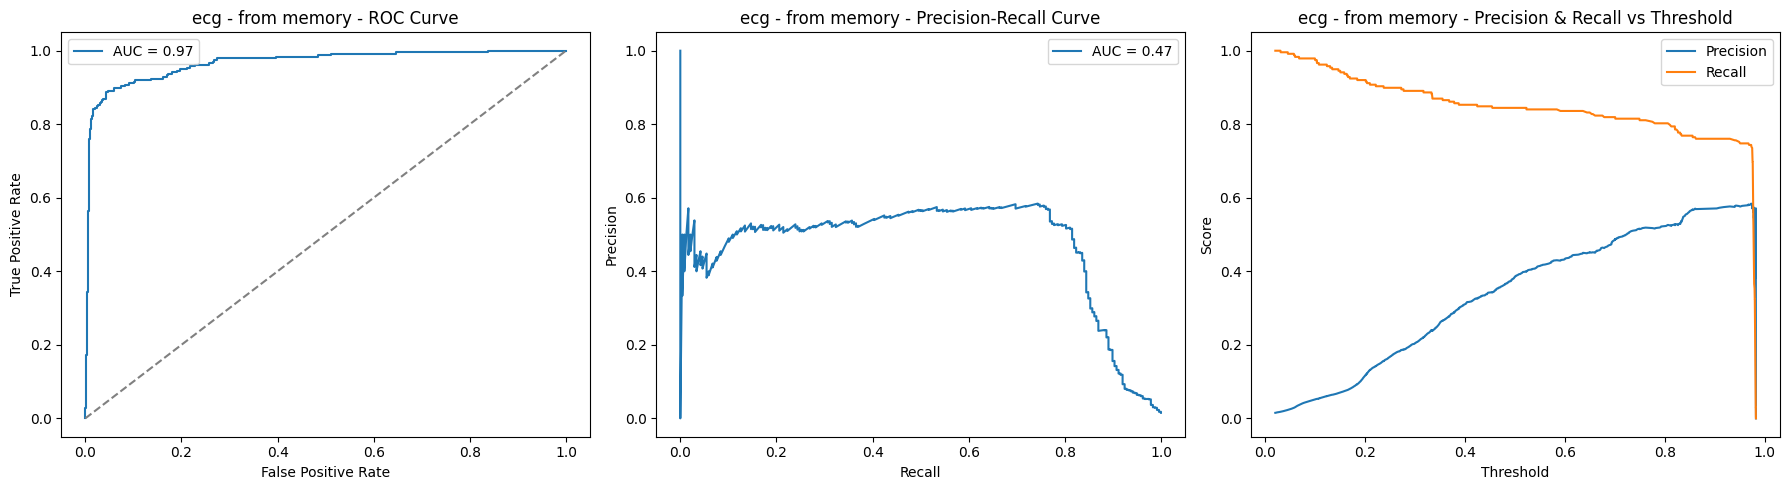

In [52]:
for mlmd_name in dataloader:
    print(mlmd_name.upper())
    model_tester = TestEvaluator(models[mlmd_name]['model'])
    trainer = pl.Trainer(accelerator="gpu", devices=1)
    trainer.test(model_tester, dataloaders=dataloader[mlmd_name]['test'])
    plot_metrics(f"{mlmd_name} - from memory", model_tester.probs, model_tester.labels)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


ECG


Testing: |          | 0/? [00:00<?, ?it/s]

ROC AUC: 0.9618
PR AUC:  0.5238


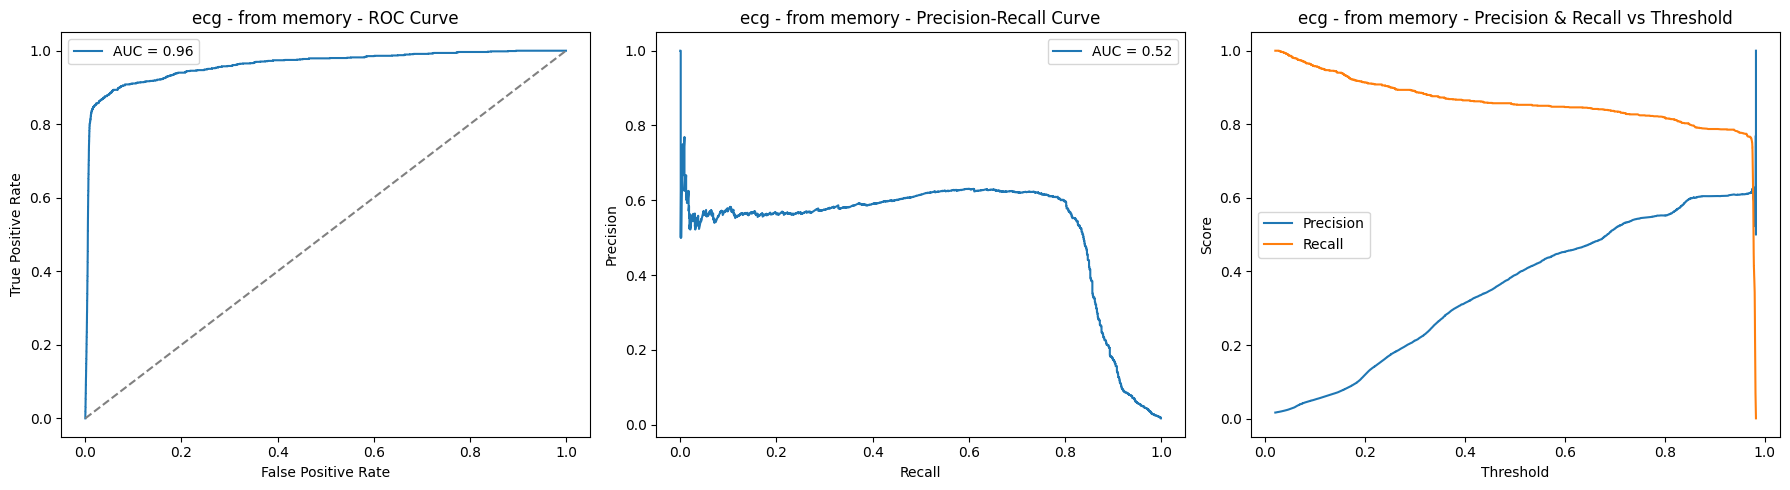

In [53]:
for mlmd_name in dataloader:
    print(mlmd_name.upper())
    model_tester = TestEvaluator(models[mlmd_name]['model'])
    trainer = pl.Trainer(accelerator="gpu", devices=1)
    trainer.test(model_tester, dataloaders=dataloader[mlmd_name]['tech_val'])
    plot_metrics(f"{mlmd_name} - from memory", model_tester.probs, model_tester.labels)

In [54]:

# all_probs_saved = []
# all_labels_saved = []

# for batch in dataloader[mlmd_name]['test']:
#     tabular_x, text1_x, text2_x, text3_x, labels = batch

#     # Move tensors to CPU if needed and convert to lists of tensors
#     input_df = {
#         "x_tabular": [x.cpu().numpy().tolist() for x in tabular_x],
#         "x_text1": [x.cpu().numpy().tolist() for x in text1_x],
#         "x_text2": [x.cpu().numpy().tolist() for x in text2_x],
#         "x_text3": [x.cpu().numpy().tolist() for x in text3_x],
#     }

#     # Predict using MLflow model (returns NumPy array of probabilities)
#     probs = saved_model.predict(input_df)

#     all_probs_saved.append(probs)
#     all_labels_saved.append(labels.cpu().numpy())

# # Concatenate results
# import numpy as np
# all_probs_saved = np.concatenate(all_probs_saved)
# all_labels_saved = np.concatenate(all_labels_saved)

In [55]:
for mlmd_name in dataloader:
    print(mlmd_name.upper())
    path = f'./raw_torch_models/{mlmd_name}_torch_model.pth'
    torch.save(models[mlmd_name]['model'], path)

ECG


In [56]:
for mlmd_name in dataloader:
    print(mlmd_name.upper())
    path = f'./raw_torch_models/{mlmd_name}_transformer_lt_checkpoint_model.pth'
    # torch.save(models[mlmd_name]['model'], path)
    models[mlmd_name]['trainer'].save_checkpoint(path)

`weights_only` was not set, defaulting to `False`.


ECG


In [58]:
pl_saved_models = {}

for mlmd_name in dataloader:
    print(mlmd_name.upper())
    path = f'./raw_torch_models/{mlmd_name}_transformer_lt_checkpoint_model.pth'
    # torch.save(models[mlmd_name]['model'], path)
    # models[mlmd_name]['trainer'].save_checkpoint(path)
    pl_saved_models[mlmd_name] = FusionLightningModule.load_from_checkpoint(path, weights_only=False)

pl_saved_models

ECG


{'ecg': FusionLightningModule(
   (model): MultiModalFusionTransformer(
     (tabular_proj): Sequential(
       (0): Linear(in_features=27, out_features=512, bias=True)
       (1): ReLU()
       (2): Dropout(p=0.1, inplace=False)
       (3): Linear(in_features=512, out_features=256, bias=True)
       (4): ReLU()
     )
     (layers): ModuleList(
       (0-3): 4 x TransformerEncoderLayer(
         (self_attn): MultiheadAttention(
           (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
         )
         (linear1): Linear(in_features=256, out_features=1024, bias=True)
         (dropout): Dropout(p=0.1, inplace=False)
         (linear2): Linear(in_features=1024, out_features=256, bias=True)
         (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
         (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
         (dropout1): Dropout(p=0.1, inplace=False)
         (dropout2): Dropout(p=0.1, inplace=False)
       )
  

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


ECG


Testing: |          | 0/? [00:00<?, ?it/s]

ROC AUC: 0.9669
PR AUC:  0.4715


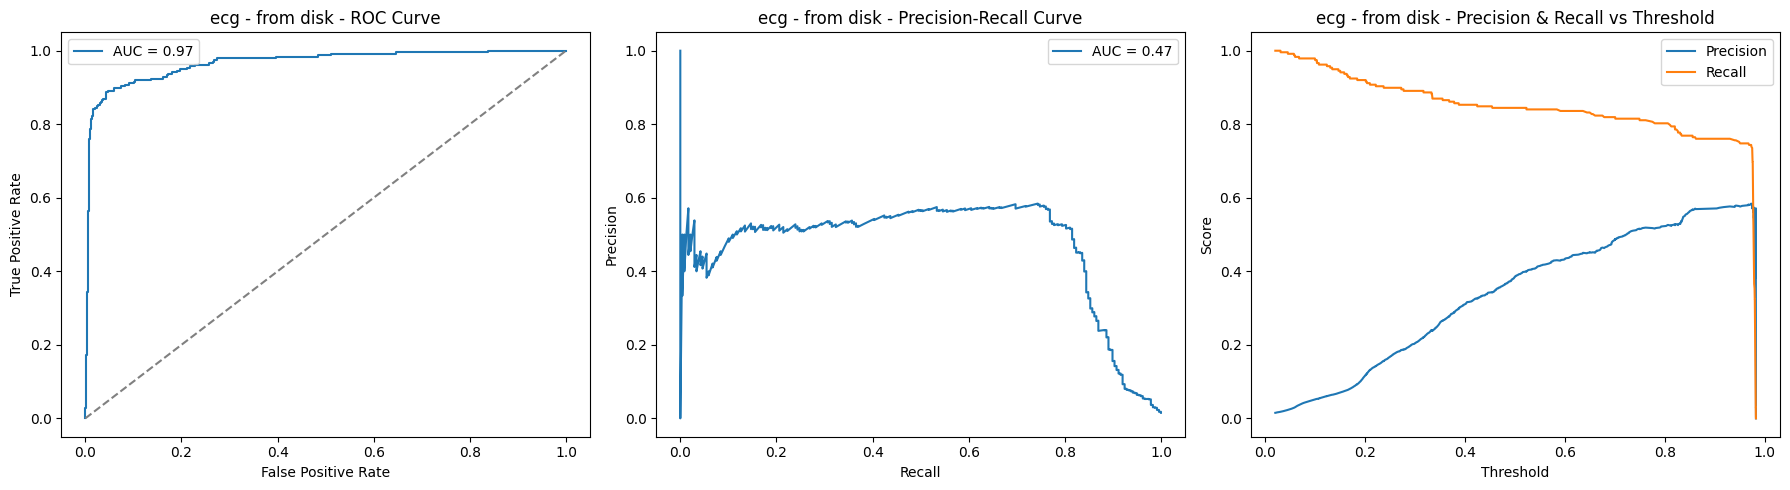

In [59]:
for mlmd_name in dataloader:
    print(mlmd_name.upper())
    model_tester = TestEvaluator(pl_saved_models[mlmd_name])
    trainer = pl.Trainer(accelerator="gpu", devices=1)
    trainer.test(model_tester, dataloaders=dataloader[mlmd_name]['test'])
    plot_metrics(f"{mlmd_name} - from disk", model_tester.probs, model_tester.labels)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


ECG


Testing: |          | 0/? [00:00<?, ?it/s]

ROC AUC: 0.9618
PR AUC:  0.5238


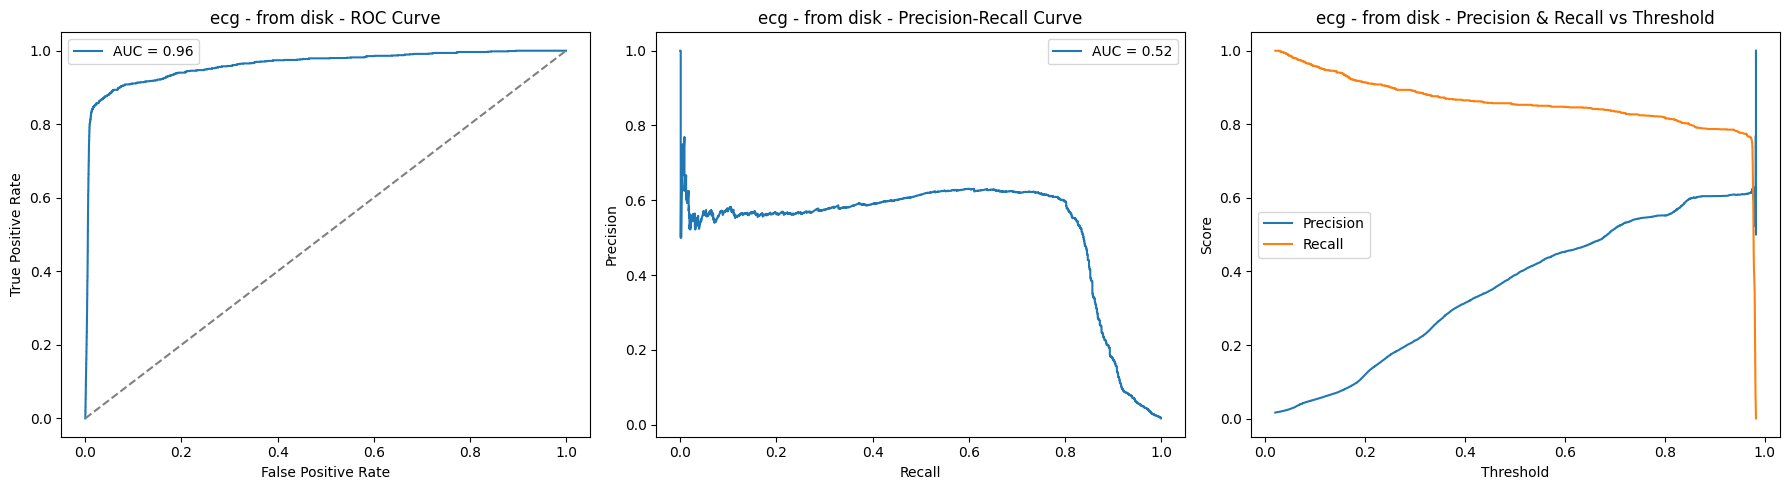

In [61]:
for mlmd_name in dataloader:
    print(mlmd_name.upper())
    model_tester = TestEvaluator(pl_saved_models[mlmd_name])
    trainer = pl.Trainer(accelerator="gpu", devices=1)
    trainer.test(model_tester, dataloaders=dataloader[mlmd_name]['tech_val'])
    plot_metrics(f"{mlmd_name} - from disk", model_tester.probs, model_tester.labels)